In [169]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [170]:
df = pd.DataFrame({'x':[2, 0.5, 1], 'y':[2, 1.5, 1]})

In [171]:
df

,x,y
0,2.0,2.0
1,0.5,1.5
2,1.0,1.0


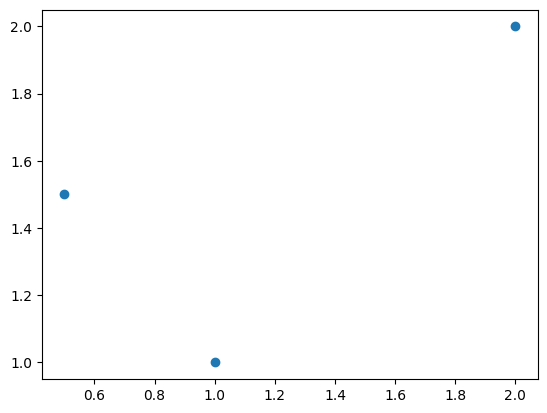

In [172]:
plt.scatter(df['x'], df['y'])

In [173]:
m, b = 1, 1

In [174]:
df['y_pred'] = df['x'] * m + b

In [175]:
df

,x,y,y_pred
0,2.0,2.0,3.0
1,0.5,1.5,1.5
2,1.0,1.0,2.0


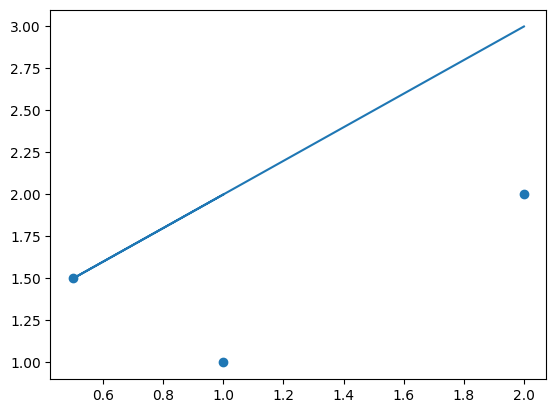

In [176]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['y_pred'])

In [177]:
df['err_abs'] = np.abs(df['y']-df['y_pred'])

In [178]:
df['err_abs'].mean()

0.6666666666666666

In [179]:
df['m_change'] = df['x'] * (df['y']-df['y_pred'])/np.abs(df['y']-df['y_pred'])

In [180]:
df

,x,y,y_pred,err_abs,m_change
0,2.0,2.0,3.0,1.0,-2.0
1,0.5,1.5,1.5,0.0,NaN
2,1.0,1.0,2.0,1.0,-1.0


In [181]:
df['m_change'] = df['x'] * np.sign(df['y']-df['y_pred'])

In [182]:
df

,x,y,y_pred,err_abs,m_change
0,2.0,2.0,3.0,1.0,-2.0
1,0.5,1.5,1.5,0.0,0.0
2,1.0,1.0,2.0,1.0,-1.0


In [183]:
df['m_change'].mean()

-1.0

In [184]:
df['b_change'] = np.sign(df['y']-df['y_pred'])

In [185]:
df['b_change'].mean()

-0.6666666666666666

In [186]:
nu = 0.1

In [187]:
m , b

(1, 1)

In [188]:
m = m + nu * df['m_change'].mean()
b = b + nu * df['b_change'].mean()

In [189]:
m , b

(0.9, 0.9333333333333333)

In [190]:
df['y_pred'] = df['x'] * m + b

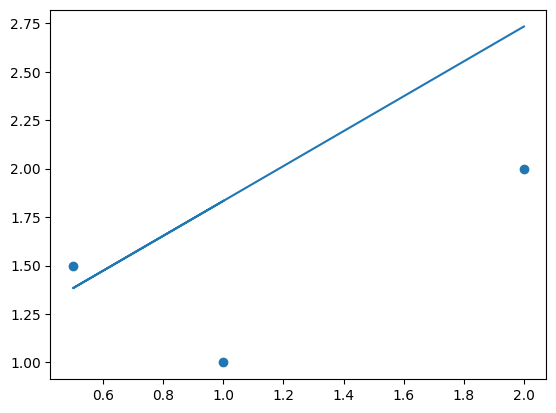

In [191]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['y_pred'])

In [192]:
df['err_abs'] = np.abs(df['y']-df['y_pred'])

In [193]:
df['err_abs'].mean()

0.5611111111111112

In [194]:
df = df[['x', 'y']].copy()
m, b = 1, 1
nu = 0.01
n = 100
df['y_pred'] = df['x'] * m + b
for i in range(n):
  df['m_change'] = 2*df['x']*(df['y']-df['y_pred'])
  df['b_change'] = 2*(df['y']-df['y_pred'])
  m = m + nu * df['m_change'].mean()
  b = b + nu * df['b_change'].mean()
  df['y_pred'] = df['x'] * m + b
  df['err_sq'] = (df['y']-df['y_pred'])**2
  print(df['err_sq'].mean())

0.610388888888889
0.5598031434259256
0.5143328099368275
0.4734596869848808
0.43671807343388497
0.4036894494770662
0.3739976965479255
0.3473048015171756
0.32330699611119607
0.30173128745832306
0.28233234013656167
0.2648896741109947
0.24920514655708895
0.23510068880851395
0.22241627258199384
0.21100808225040402
0.20074687228870627
0.19151649113227168
0.18321255458781924
0.17574125364531956
0.16901828307427036
0.1629678785672939
0.15752195143378223
0.1526193109604802
0.14820496555719254
0.14422949470563814
0.14064848453816448
0.13742202059977074
0.1345142320000228
0.1318928817483815
0.12952899859395736
0.12739654616474433
0.12547212562740517
0.12373470847153256
0.12216539636638006
0.12074720534726473
0.11946487186672379
0.11830467849523861
0.11725429728076436
0.11630264897799654
0.11543977653956002
0.11465673142419952
0.11394547142344118
0.11329876883975117
0.11271012796744895
0.11217371093388288
0.11168427105386362
0.11123709293616317
0.11082793865800655
0.11045299939278781
0.11010885193

In [195]:
m, b

(0.5773182553710381, 0.7997021160326249)

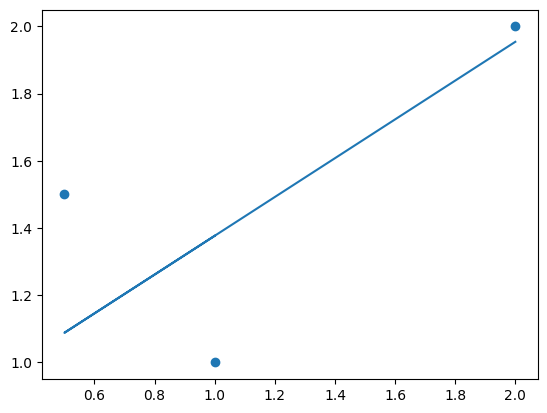

In [196]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['y_pred'])

In [197]:
df['x0'] = 1
XT = df[['x','x0']].T
XTX = XT @ df[['x','x0']]
inv = np.linalg.pinv(XTX)
theta = (inv@XT)@df['y']
theta

0    0.428571
1    1.000000
dtype: float64

In [198]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['x']], df['y'])
print(model.coef_, model.intercept_)

[0.42857143] 1.0


In [199]:
df['x'].to_numpy()

array([2. , 0.5, 1. ])

/home/tim/myenv/lib64/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


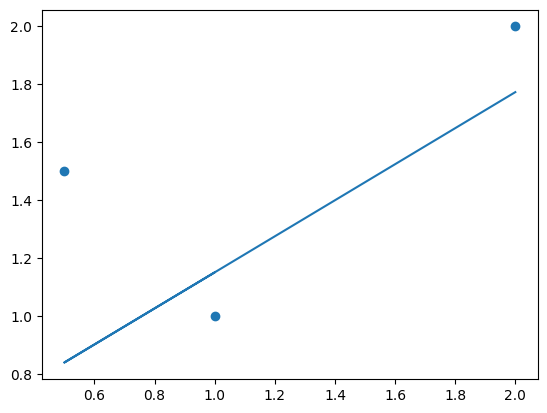

In [200]:
from sklearn.linear_model import SGDRegressor
regressor = SGDRegressor()
regressor.fit(df[['x']], df['y'])
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], regressor.predict(df[['x']].to_numpy()))

In [201]:
from sympy import *
x, y, m, b = Symbol('x', real=True), Symbol('y', real=True), Symbol('m', real=True), Symbol('b', real=True)
diff(Abs(y - x*m - b), m)

x*sign(b + m*x - y)